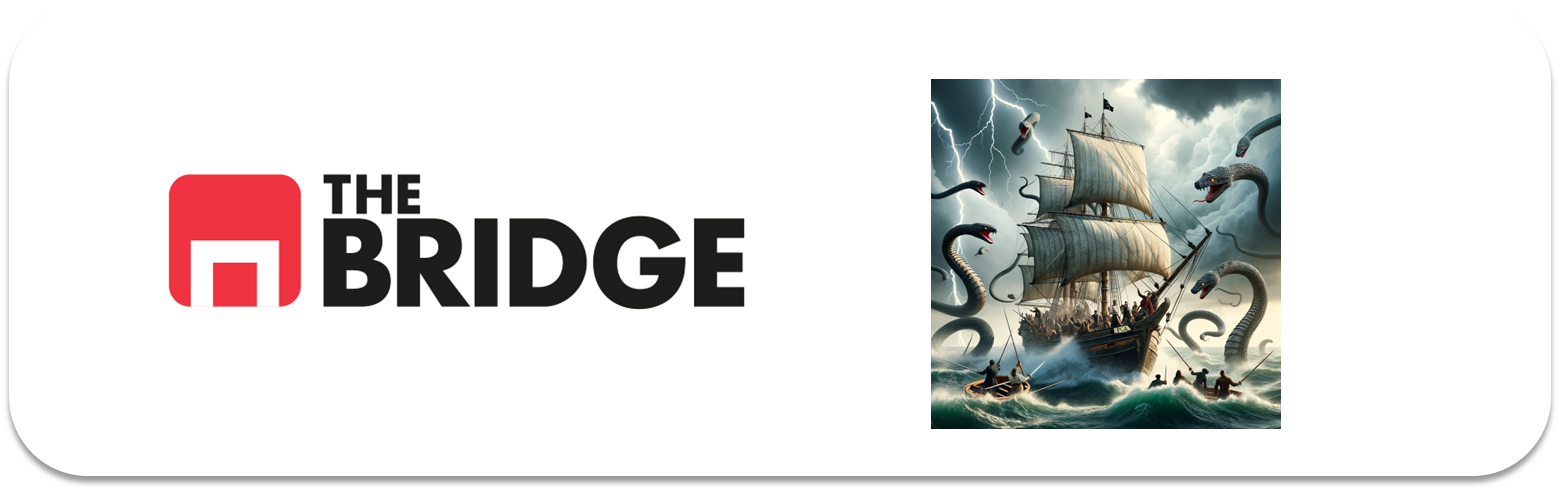

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de
diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este
notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los
directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que
puntúe adecuadamente.
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el
esfuerzo.
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará
en el repo del curso.

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técnicas de selección de
features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de
credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A
partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas
todas entre sí y escoger finalmente el conjunto más sencillo con más potencia.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from scipy.stats import mannwhitneyu

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, f_classif, mutual_info_classif,
    SelectFromModel, RFE, SequentialFeatureSelector,
)
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV


def localizar_fichero(nombre, raiz="."):
    """Busca `nombre` en el árbol de directorios a partir de `raiz`."""
    directo = os.path.join(raiz, "data", nombre)
    if os.path.exists(directo):
        return directo
    for carpeta, _, ficheros in os.walk(raiz):
        if nombre in ficheros:
            return os.path.join(carpeta, nombre)
    raise FileNotFoundError(f"No se ha encontrado '{nombre}' bajo '{raiz}'.")


ruta_bootcamp = None
for carpeta, _, ficheros in os.walk("."):
    if "bootcampviztools.py" in ficheros:
        ruta_bootcamp = os.path.join(carpeta, "bootcampviztools.py")
        break
if ruta_bootcamp is None:
    raise FileNotFoundError("No se ha encontrado 'bootcampviztools.py' junto al notebook.")
sys.path.append(os.path.dirname(os.path.abspath(ruta_bootcamp)))
import bootcampviztools as bt

np.random.seed(42)


> **Nota sobre librerías**: el enunciado original recurre a `xgboost` y `lightgbm`. Aquí
> resolvemos el ejercicio usando exclusivamente `scikit-learn`: como alternativas de
> *boosting* usamos `HistGradientBoostingClassifier` (en el papel de XGBoost) y
> `AdaBoostClassifier` sobre un árbol con `class_weight="balanced"` (en el papel de
> LightGBM), junto con `RandomForestClassifier` como modelo de bagging.

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable
"SeriousDlqin2yrs" del dataset que encontrarás en "data".

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el
dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las
   features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features:
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de
       covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features
       categóricas mediante Mutual Information
    3. Selección de las mejores features a través de un modelo intermedio (usando
       SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo
       obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera
    división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con
   validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18
   (6*3) medidas (emplea la métrica de recall medio -balanced_accuracy-, dado el desbalance
   del target). Escoge el mejor modelo y la mejor lista de features.

4. Ajusta hiperparámetros del modelo elegido, tanto sobre la lista de features ganadora como
   sobre alguna otra que te parezca razonable comparar, y evalúa contra test.

In [2]:
ruta_csv = localizar_fichero("credit_npo.csv")
df = pd.read_csv(ruta_csv)
df


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
12532,0,0.197116,59,0,0.290216,5140.0,6,0,1,0,0.0
12533,0,0.036726,62,0,0.884985,5833.0,12,0,1,0,0.0
12534,0,0.120313,49,0,0.577676,6333.0,7,0,2,0,2.0
12535,0,0.252566,63,0,0.037640,14000.0,9,0,0,0,1.0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

In [4]:
df = df.dropna().reset_index(drop=True)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11816 entries, 0 to 11815
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      11816 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  11816 non-null  float64
 2   age                                   11816 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  11816 non-null  int64  
 4   DebtRatio                             11816 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       11816 non-null  int64  
 7   NumberOfTimes90DaysLate               11816 non-null  int64  
 8   NumberRealEstateLoansOrLines          11816 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  11816 non-null  int64  
 10  NumberOfDependents                    11816 non-null  float64
dtypes: float64(4), 

In [5]:
target = "SeriousDlqin2yrs"


3. Train y Test

In [6]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42, stratify=df[target])


4. MiniEDA

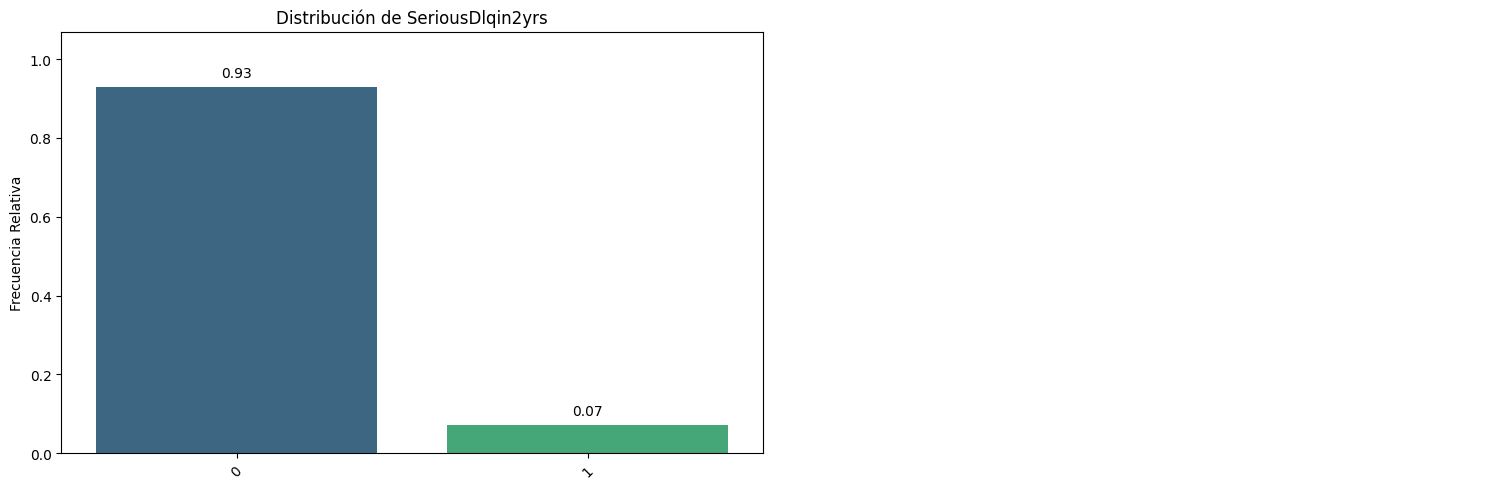

In [7]:
bt.pinta_distribucion_categoricas(train_set, [target], True, True)


In [8]:
train_set.describe().T


,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,9452.0,0.070250,0.255581,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,9452.0,0.336250,0.367448,0.0,0.034696,0.177681,0.587535,6.0
age,9452.0,51.473445,14.582557,21.0,41.000000,51.000000,62.000000,101.0
NumberOfTime30-59DaysPastDueNotWorse,9452.0,0.362146,3.252785,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,9452.0,0.507346,2.711252,0.0,0.144282,0.295119,0.478447,96.0
MonthlyIncome,9452.0,6927.238785,12765.288137,0.0,3498.750000,5450.000000,8333.000000,702500.0
NumberOfOpenCreditLinesAndLoans,9452.0,8.750529,5.118403,0.0,5.000000,8.000000,11.000000,49.0
NumberOfTimes90DaysLate,9452.0,0.194985,3.218289,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,9452.0,1.067605,1.155821,0.0,0.000000,1.000000,2.000000,19.0
NumberOfTime60-89DaysPastDueNotWorse,9452.0,0.170123,3.202581,0.0,0.000000,0.000000,0.000000,98.0


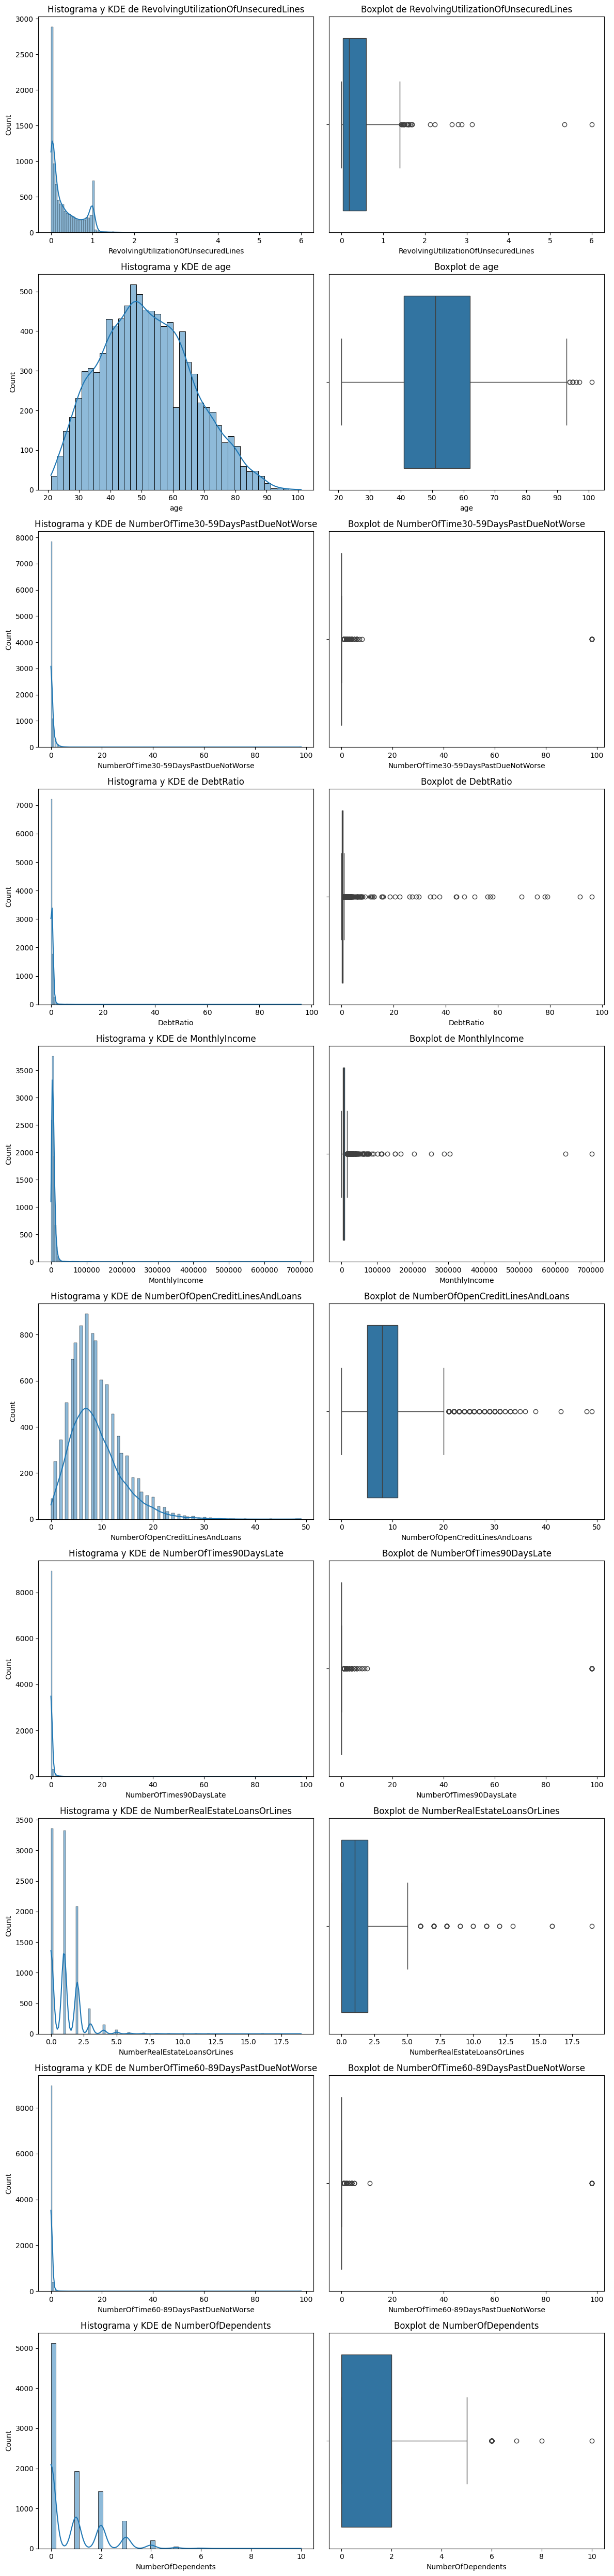

In [9]:
bt.plot_combined_graphs(train_set, [col for col in train_set.columns if col != target])


* *RevolvingUtilizationOfUnsecuredLines*: numérica continua.
* *age*: numérica discreta.
* *NumberOfTime30-59DaysPastDueNotWorse*: el valor 98 la distorsiona; mirando sus cuantiles
  (0) y el combinado histograma+caja, es claramente categorizable. Haremos un value_counts
  para decidir la categorización.
* *DebtRatio*: la consideramos numérica continua, por rango y valores.
* *MonthlyIncome*: numérica continua.
* *NumberOfOpenCreditLinesAndLoans*: numérica discreta, pero por la cantidad de valores la
  tratamos como continua.
* *NumberOfTimes90DaysLate*: le pasa lo mismo que a la anterior "NumberOfTime...";
  miraremos su value_counts para categorizarla.
* *NumberRealEstateLoansOrLines*: tiene outliers dispersos pero parece concentrada en 5
  valores; miraremos su value_counts y su relación con el target antes de decidir (
  probablemente categorizarla).
* *NumberOfTime60-89DaysPastDueNotWorse*: igual que las otras dos "NumberOfTime...", se
  concentra en 0 y tiene outliers sesgados por el valor 98. La categorizaremos tras ver su
  value_counts.
* *NumberOfDependents*: numérica discreta que no tocaremos.

In [10]:
features_num = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfDependents",
]


In [11]:
train_set["NumberOfDependents"].value_counts(normalize=True) * 100


NumberOfDependents
0.0     54.274228
1.0     20.366060
2.0     15.033855
3.0      7.352941
4.0      2.158273
5.0      0.560728
6.0      0.222175
10.0     0.010580
7.0      0.010580
8.0      0.010580
Name: proportion, dtype: float64

In [12]:
columnas_numberof = [col for col in df.columns if col.startswith("NumberOf")]
for columna in columnas_numberof:
    distribucion = df[columna].value_counts(normalize=True, dropna=False).sort_index()
    pct_ceros = distribucion.get(0, 0)
    print(f"\n{columna} | valores_unicos = {df[columna].nunique()} | porcentaje_0 = {pct_ceros:.2%}")
    print((distribucion.head(10) * 100).round(2))



NumberOfTime30-59DaysPastDueNotWorse | valores_unicos = 10 | porcentaje_0 = 83.09%
NumberOfTime30-59DaysPastDueNotWorse
0     83.09
1     11.46
2      3.36
3      1.07
4      0.54
5      0.19
6      0.17
7      0.01
8      0.02
98     0.08
Name: proportion, dtype: float64

NumberOfOpenCreditLinesAndLoans | valores_unicos = 43 | porcentaje_0 = 0.95%
NumberOfOpenCreditLinesAndLoans
0    0.95
1    2.60
2    3.77
3    5.40
4    7.18
5    8.15
6    8.73
7    9.39
8    8.54
9    8.17
Name: proportion, dtype: float64

NumberOfTimes90DaysLate | valores_unicos = 13 | porcentaje_0 = 94.41%
NumberOfTimes90DaysLate
0    94.41
1     3.33
2     1.20
3     0.46
4     0.26
5     0.12
6     0.05
7     0.03
8     0.03
9     0.01
Name: proportion, dtype: float64

NumberOfTime60-89DaysPastDueNotWorse | valores_unicos = 8 | porcentaje_0 = 94.84%
NumberOfTime60-89DaysPastDueNotWorse
0     94.84
1      4.05
2      0.72
3      0.15
4      0.12
5      0.03
11     0.01
98     0.08
Name: proportion, dtype: floa

In [13]:
train_set["NumberRealEstateLoansOrLines"].value_counts(normalize=True) * 100


NumberRealEstateLoansOrLines
0     35.558612
1     35.209479
2     22.048244
3      4.337706
4      1.576386
5      0.687685
6      0.232755
7      0.116377
8      0.074058
11     0.042319
9      0.031739
10     0.021160
12     0.021160
16     0.021160
13     0.010580
19     0.010580
Name: proportion, dtype: float64

In [14]:
features_num.append("NumberRealEstateLoansOrLines")


In [15]:
features_num


['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents',
 'NumberRealEstateLoansOrLines']

In [16]:
train_set["NumberOfTime30-59DaysPastDueNotWorse"].value_counts(normalize=True)


NumberOfTime30-59DaysPastDueNotWorse
0     0.829454
1     0.114896
2     0.034596
3     0.011109
4     0.005396
5     0.001799
6     0.001481
98    0.001058
7     0.000106
8     0.000106
Name: proportion, dtype: float64

In [17]:
columna_corta = "NumberOfTime30-59DaysPastDueNotWorse"
train_set[train_set[target] == 0][columna_corta].value_counts(normalize=True)


NumberOfTime30-59DaysPastDueNotWorse
0     0.853550
1     0.104802
2     0.027538
3     0.008193
4     0.003414
5     0.001138
6     0.000797
98    0.000341
7     0.000114
8     0.000114
Name: proportion, dtype: float64

In [18]:
columna_corta = "NumberOfTime30-59DaysPastDueNotWorse"
train_set[train_set[target] == 1][columna_corta].value_counts(normalize=True)


NumberOfTime30-59DaysPastDueNotWorse
0     0.510542
1     0.248494
2     0.128012
3     0.049699
4     0.031627
98    0.010542
6     0.010542
5     0.010542
Name: proportion, dtype: float64

In [19]:
# Nos simplificamos la vida con un alias corto
columna_corta = "NumberOfTime30-59DaysPastDueNotWorse"

# Con pd.cut
etiquetas = [0, 1, 2]

train_set["N30-59"] = pd.cut(train_set[columna_corta], bins=[-1, 0, 1, np.inf], labels=etiquetas, right=True).astype(int)
test_set["N30-59"] = pd.cut(test_set[columna_corta], bins=[-1, 0, 1, np.inf], labels=etiquetas, right=True).astype(int)
train_set["N30-59"].value_counts(normalize=True)


N30-59
0    0.829454
1    0.114896
2    0.055650
Name: proportion, dtype: float64

In [20]:
train_set[train_set[target] == 1]["N30-59"].value_counts(normalize=True)


N30-59
0    0.510542
1    0.248494
2    0.240964
Name: proportion, dtype: float64

In [21]:
train_set["NumberOfTime60-89DaysPastDueNotWorse"].value_counts(normalize=True)


NumberOfTime60-89DaysPastDueNotWorse
0     0.948688
1     0.040203
2     0.006771
3     0.001587
4     0.001164
98    0.001058
5     0.000423
11    0.000106
Name: proportion, dtype: float64

In [22]:
train_set["NumberOfTime60-89DaysPastDueNotWorse"] != 0


1907     False
9755     False
465      False
9745     False
3814     False
         ...  
4123     False
5436     False
7048     False
11026    False
4927     False
Name: NumberOfTime60-89DaysPastDueNotWorse, Length: 9452, dtype: bool

In [23]:
(train_set["NumberOfTime60-89DaysPastDueNotWorse"] != 0).astype(int)


1907     0
9755     0
465      0
9745     0
3814     0
        ..
4123     0
5436     0
7048     0
11026    0
4927     0
Name: NumberOfTime60-89DaysPastDueNotWorse, Length: 9452, dtype: int64

In [24]:
train_set["N60-89"] = (train_set["NumberOfTime60-89DaysPastDueNotWorse"] > 0).astype(int)
test_set["N60-89"] = (test_set["NumberOfTime60-89DaysPastDueNotWorse"] > 0).astype(int)
train_set["N60-89"].value_counts(normalize=True)


N60-89
0    0.948688
1    0.051312
Name: proportion, dtype: float64

In [25]:
train_set[train_set[target] == 1]["N60-89"].value_counts(normalize=True)


N60-89
0    0.740964
1    0.259036
Name: proportion, dtype: float64

In [26]:
train_set[train_set[target] == 0]["N60-89"].value_counts(normalize=True)


N60-89
0    0.964383
1    0.035617
Name: proportion, dtype: float64

In [27]:
train_set["NumberOfTimes90DaysLate"].value_counts(normalize=True)


NumberOfTimes90DaysLate
0     0.944985
1     0.033432
2     0.011955
3     0.004338
4     0.002433
98    0.001058
5     0.000846
6     0.000423
8     0.000212
10    0.000106
9     0.000106
7     0.000106
Name: proportion, dtype: float64

In [28]:
train_set["N90"] = (train_set["NumberOfTimes90DaysLate"] > 0).astype(int)
test_set["N90"] = (test_set["NumberOfTimes90DaysLate"] > 0).astype(int)
train_set["N90"].value_counts(normalize=True)


N90
0    0.944985
1    0.055015
Name: proportion, dtype: float64

In [29]:
train_set[train_set[target] == 1]["N90"].value_counts(normalize=True)


N90
0    0.652108
1    0.347892
Name: proportion, dtype: float64

In [30]:
train_set[train_set[target] == 0]["N90"].value_counts(normalize=True)


N90
0    0.967114
1    0.032886
Name: proportion, dtype: float64

In [31]:
features_cat = ["N30-59", "N60-89", "N90"]
features_cat


['N30-59', 'N60-89', 'N90']

In [32]:
features_num


['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents',
 'NumberRealEstateLoansOrLines']

In [33]:
target


'SeriousDlqin2yrs'

4.3 **Análisis visual con estadísticos matemáticos**

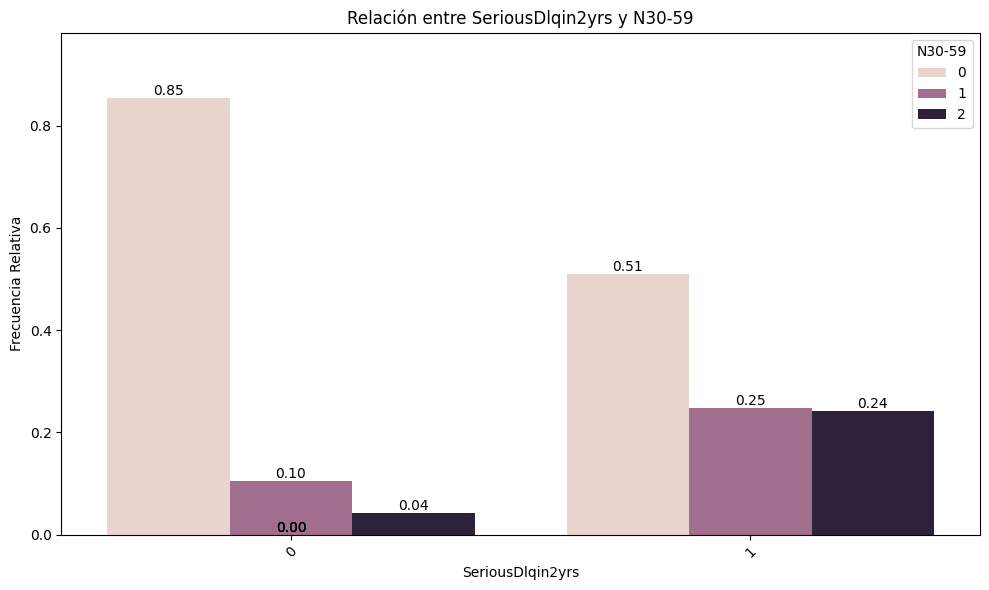

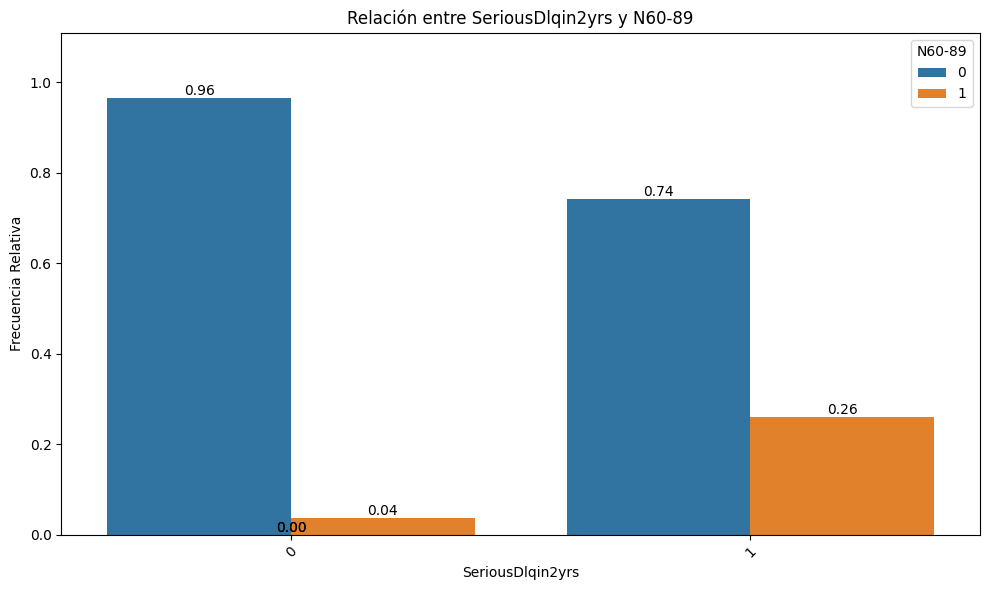

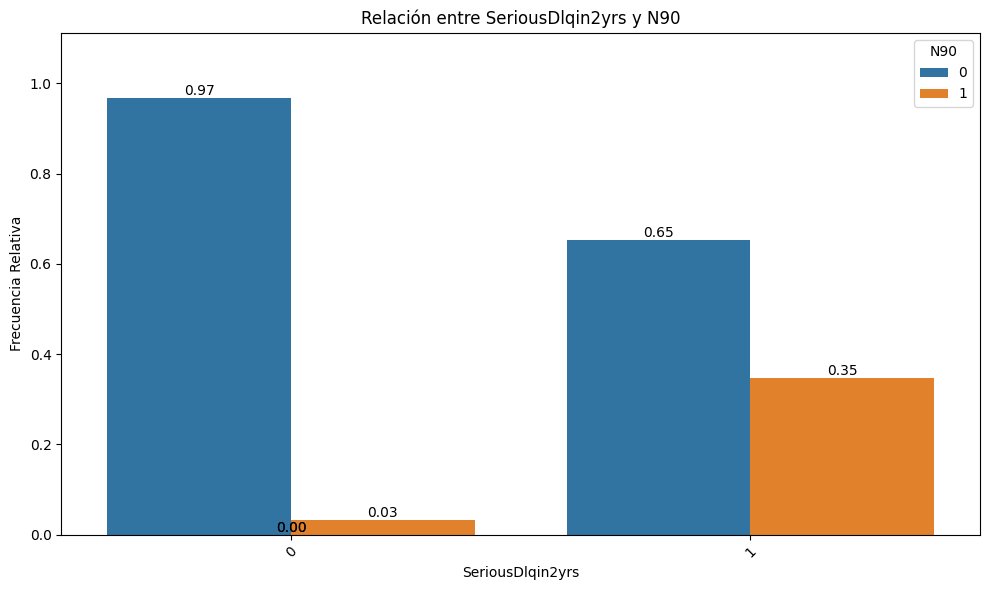

In [34]:
for columna in features_cat:
    bt.plot_categorical_relationship(train_set, target, columna, True, True)


In [35]:
features_visual = features_cat.copy()


In [36]:
len(features_num + [target])


8

In [37]:
# sns.pairplot(train_set[features_num + [target]], hue=target)


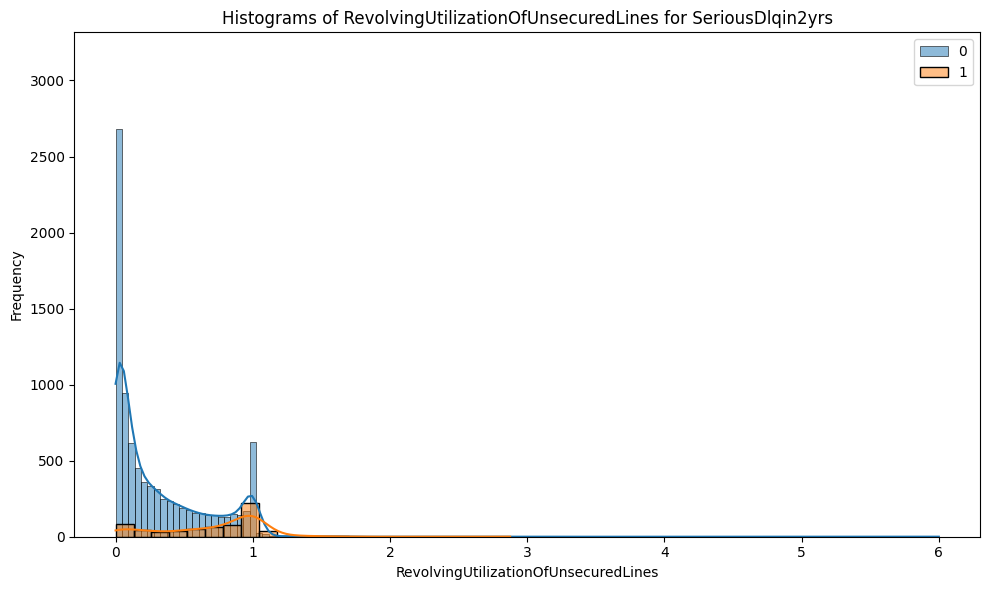

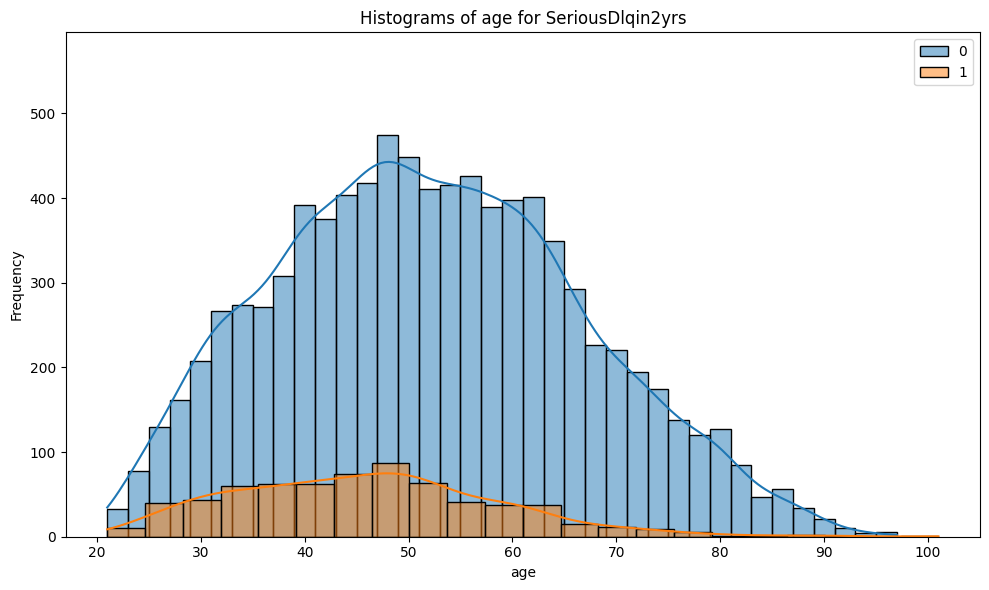

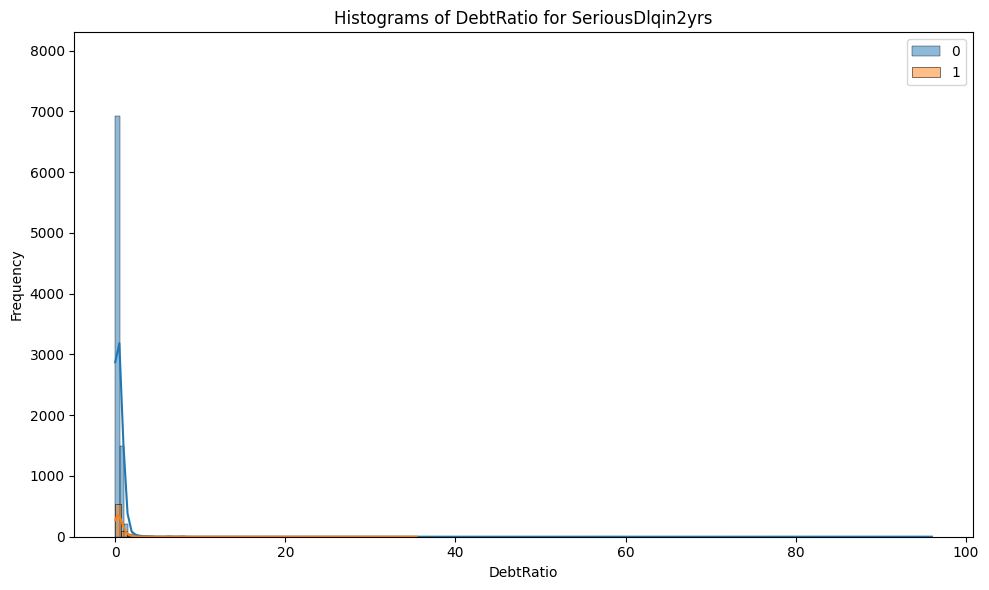

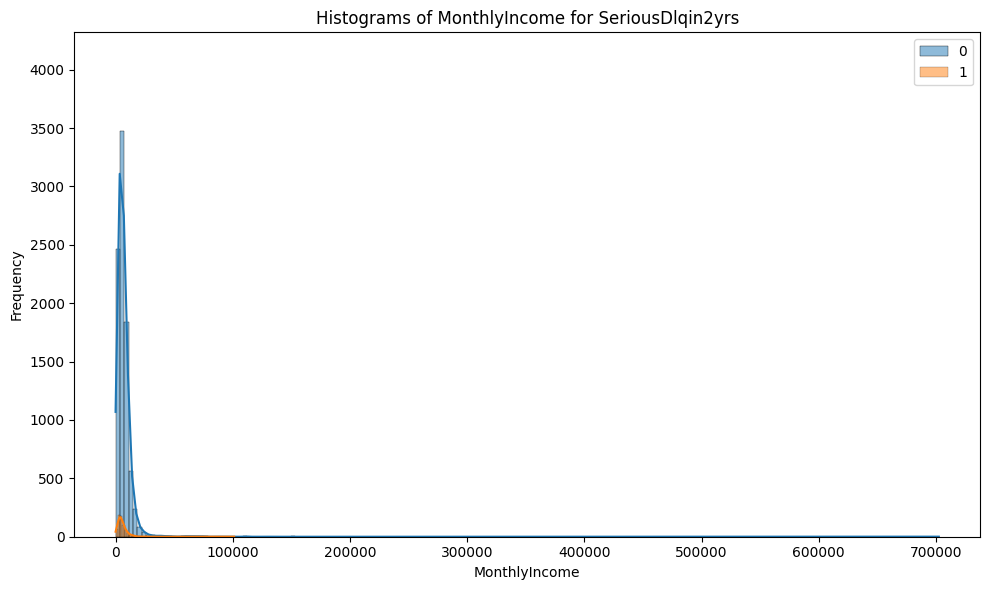

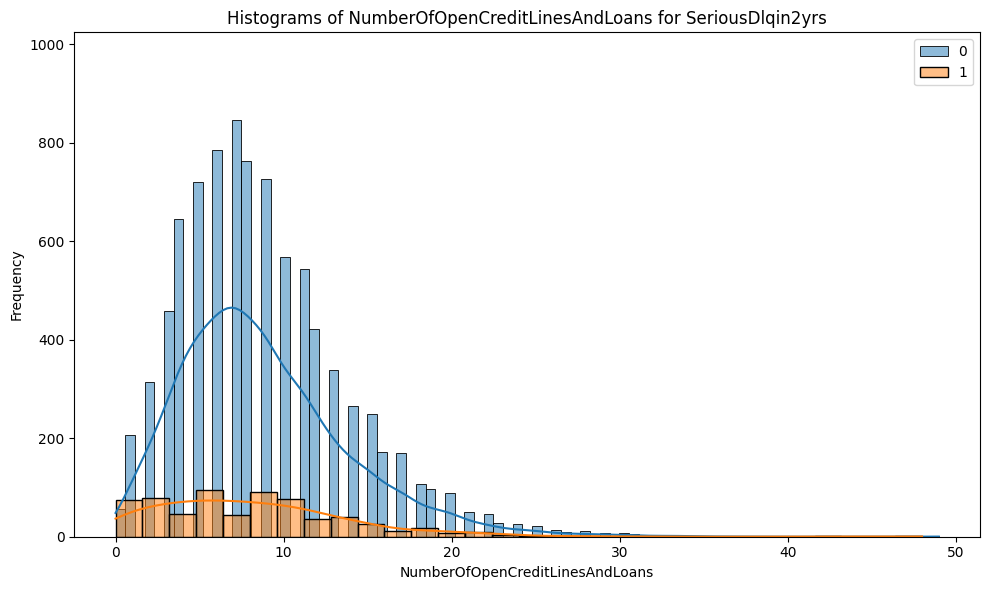

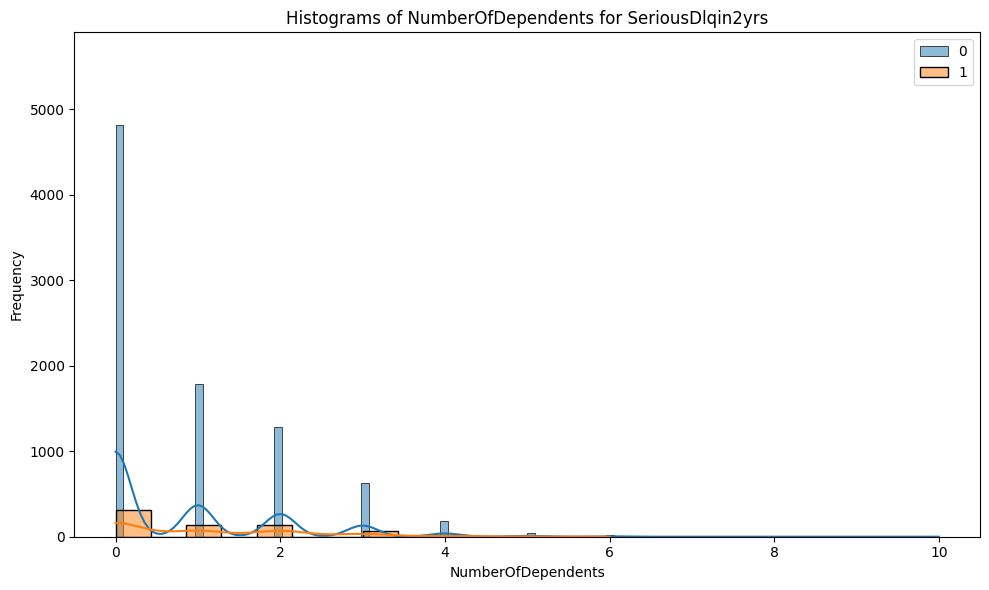

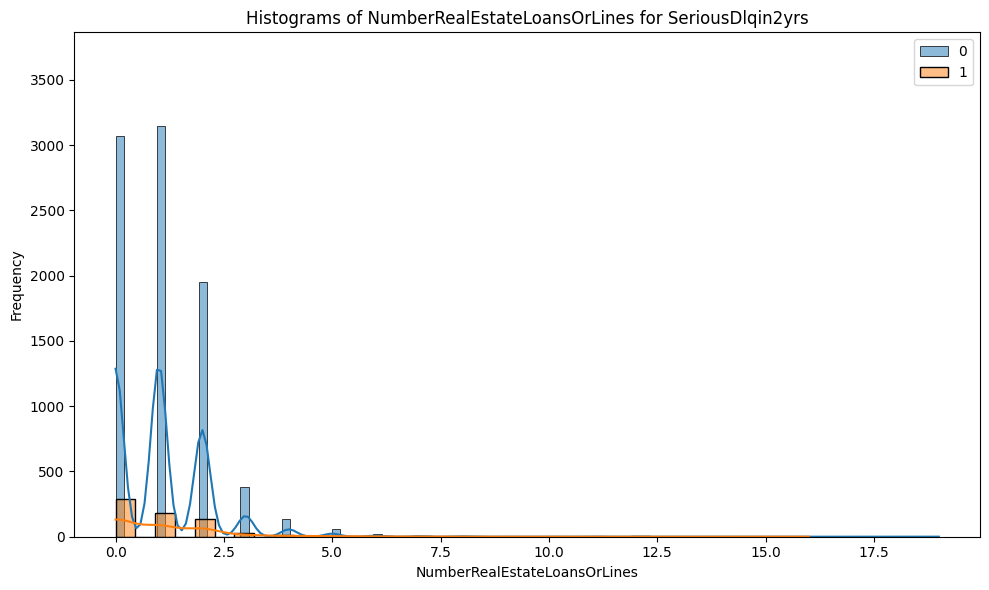

In [38]:
for columna in features_num:
    bt.plot_grouped_histograms(train_set, cat_col=target, num_col=columna, group_size=2)


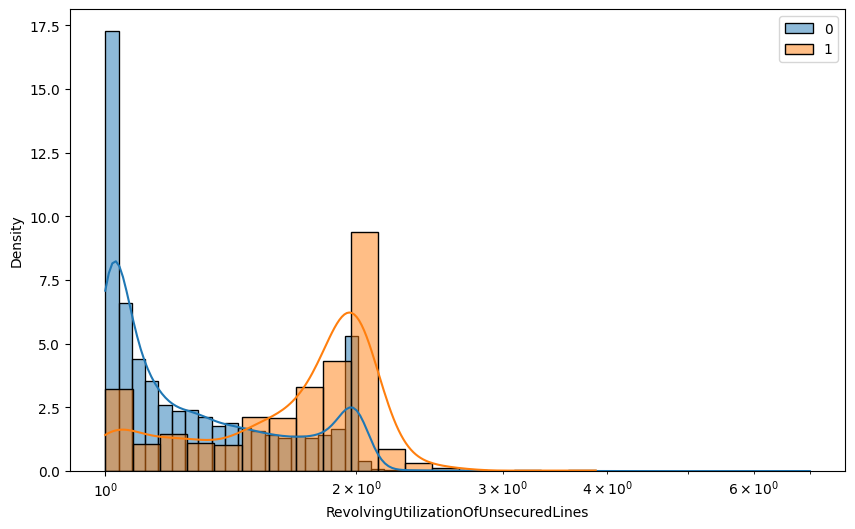

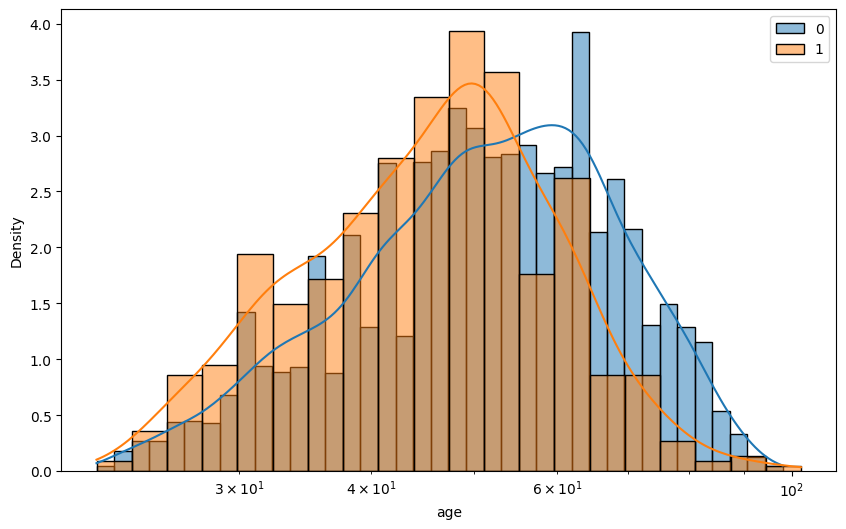

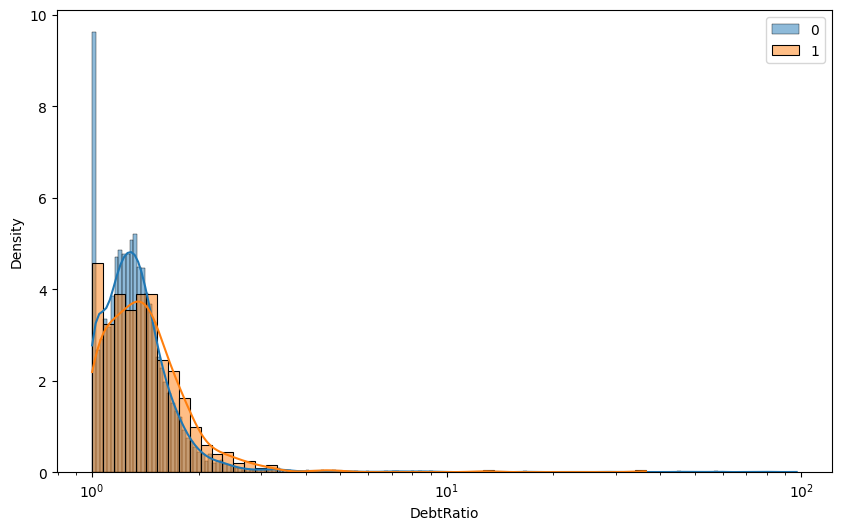

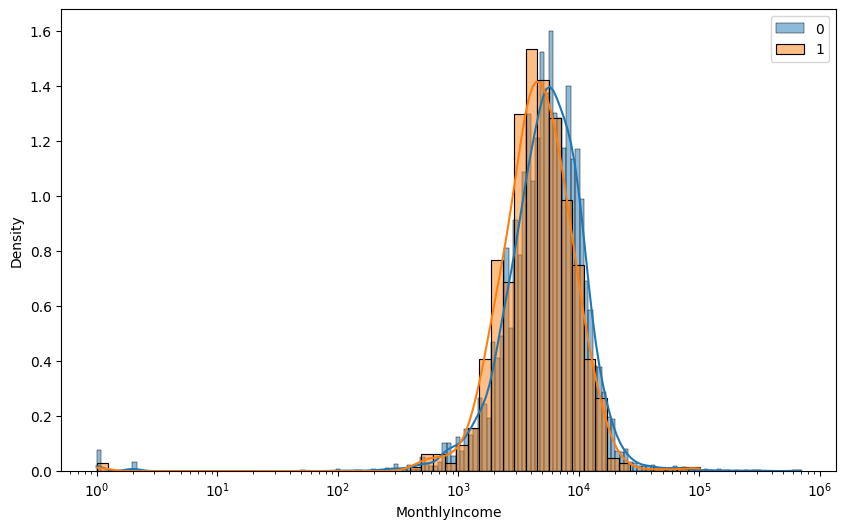

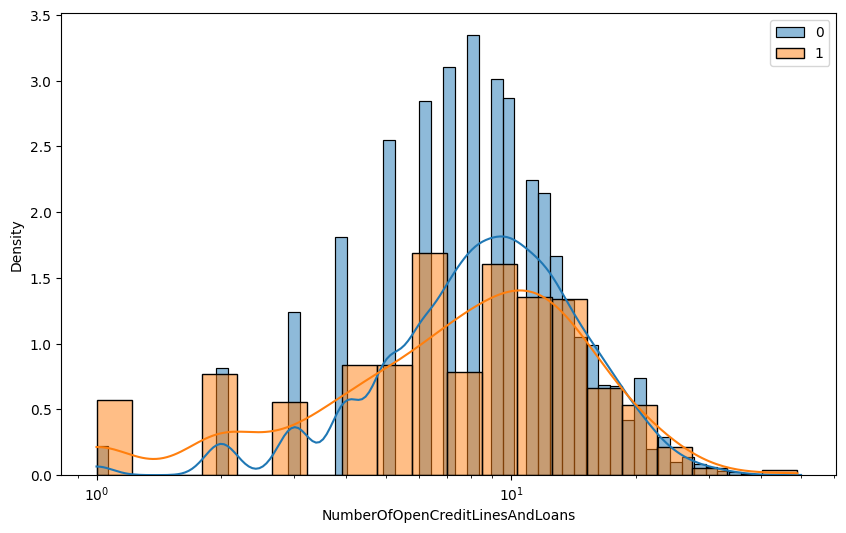

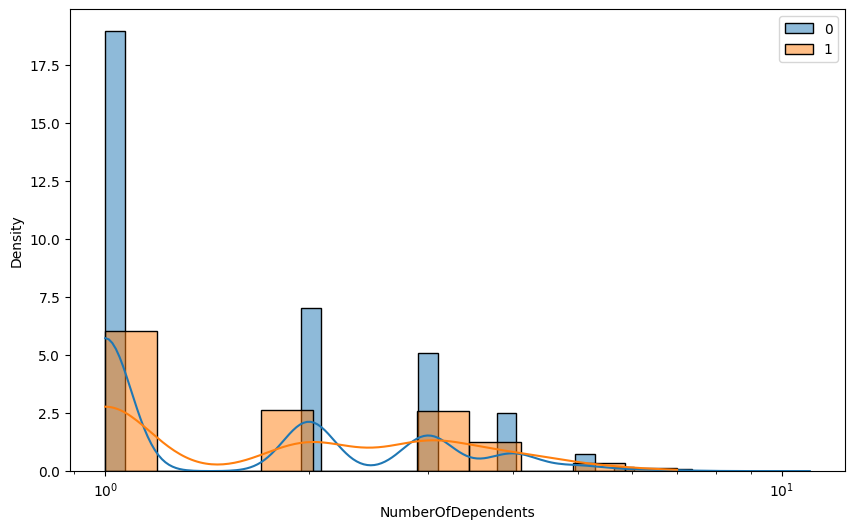

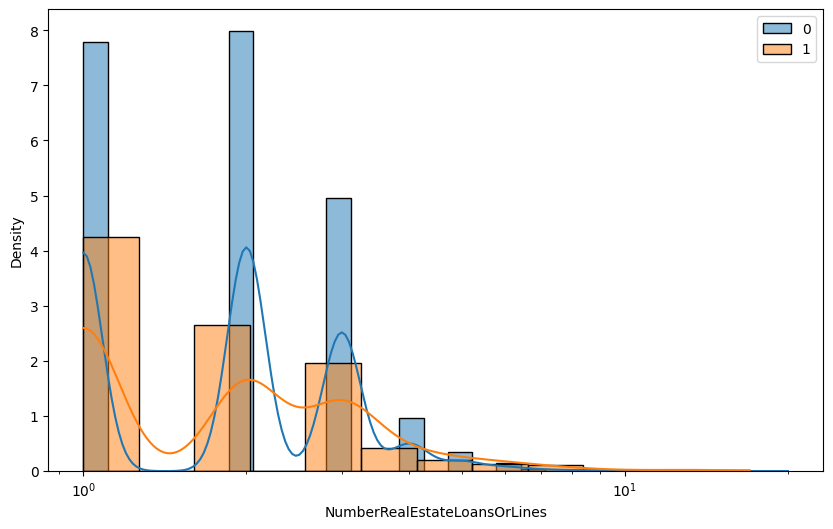

In [39]:
for columna in features_num:
    plt.figure(figsize=(10, 6))
    sns.histplot(train_set.loc[df[target] == 0] + 1, x=columna, kde=True, stat="density", log_scale=10, label="0")
    sns.histplot(train_set.loc[df[target] == 1] + 1, x=columna, kde=True, stat="density", log_scale=10, label="1")
    plt.legend()
    plt.show()


In [40]:
features_visual.append("RevolvingUtilizationOfUnsecuredLines")


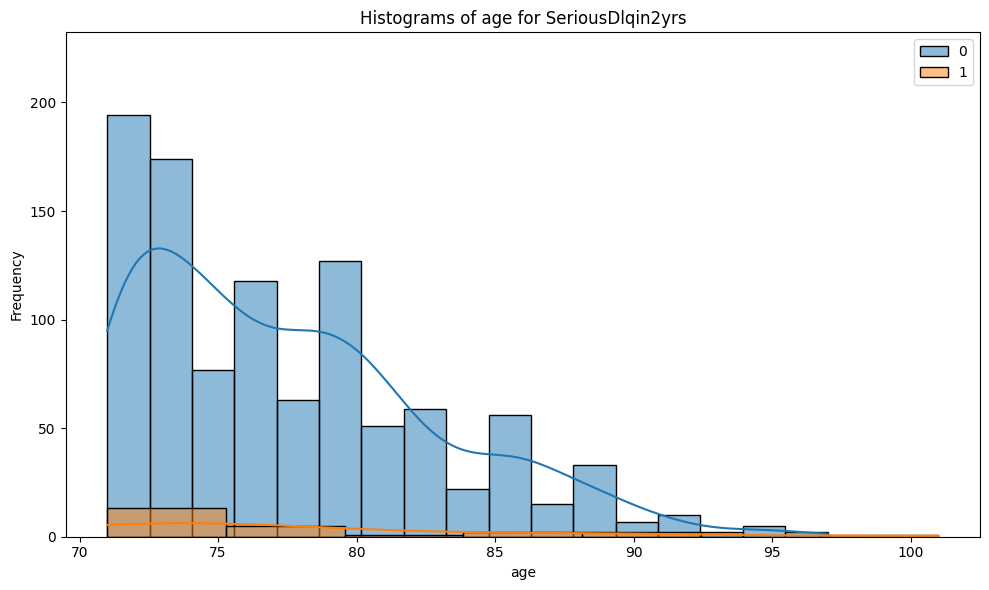

In [41]:
filtro_edad = (train_set["age"] > 70)
bt.plot_grouped_histograms(train_set[filtro_edad], cat_col=target, num_col="age", group_size=2)


In [42]:
features_visual.append("age")


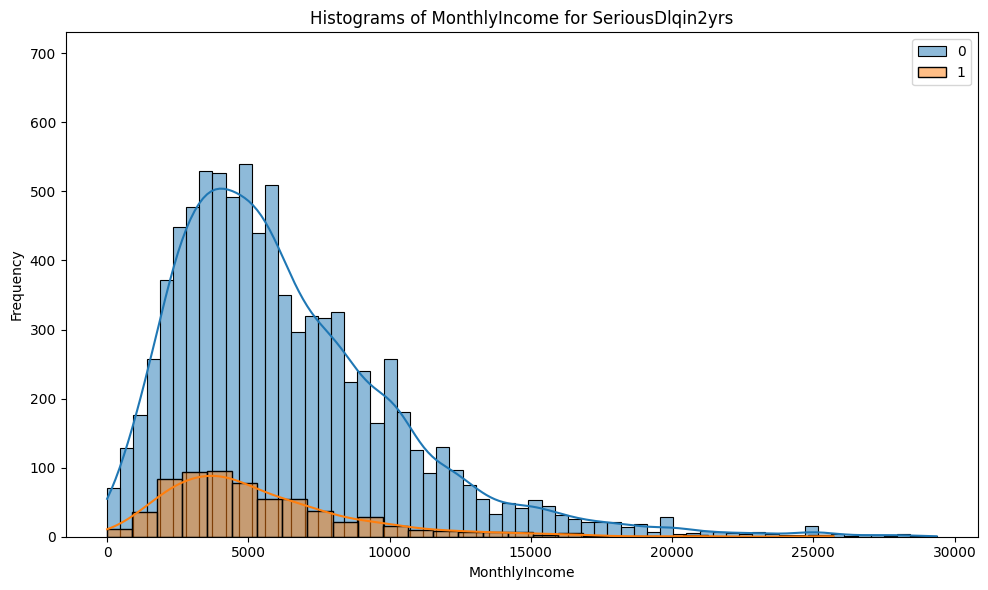

In [43]:
sin_outliers_ingreso = train_set["MonthlyIncome"] < 30000  # umbral escogido mirando el boxplot; a partir de 20000 ya hay muchos outliers, 30000 o 20000 dan un resultado similar
bt.plot_grouped_histograms(train_set[sin_outliers_ingreso], cat_col=target, num_col="MonthlyIncome", group_size=2)


In [44]:
columna_cat = target
columna_num = "MonthlyIncome"

grupo_a = train_set.loc[train_set[columna_cat] == 0][columna_num]
grupo_b = train_set.loc[train_set[columna_cat] == 1][columna_num]

estadistico_u, p_valor = mannwhitneyu(grupo_a, grupo_b)

print("Estadístico U:", estadistico_u)
print("Valor p:", p_valor)


Estadístico U: 3344578.5
Valor p: 3.0229710728481514e-10


In [45]:
p_valor < 0.05


np.True_

In [46]:
features_visual.append("MonthlyIncome")


In [47]:
train_set["DebtRatio"].describe()


count    9452.000000
mean        0.507346
std         2.711252
min         0.000000
25%         0.144282
50%         0.295119
75%         0.478447
max        96.000000
Name: DebtRatio, dtype: float64

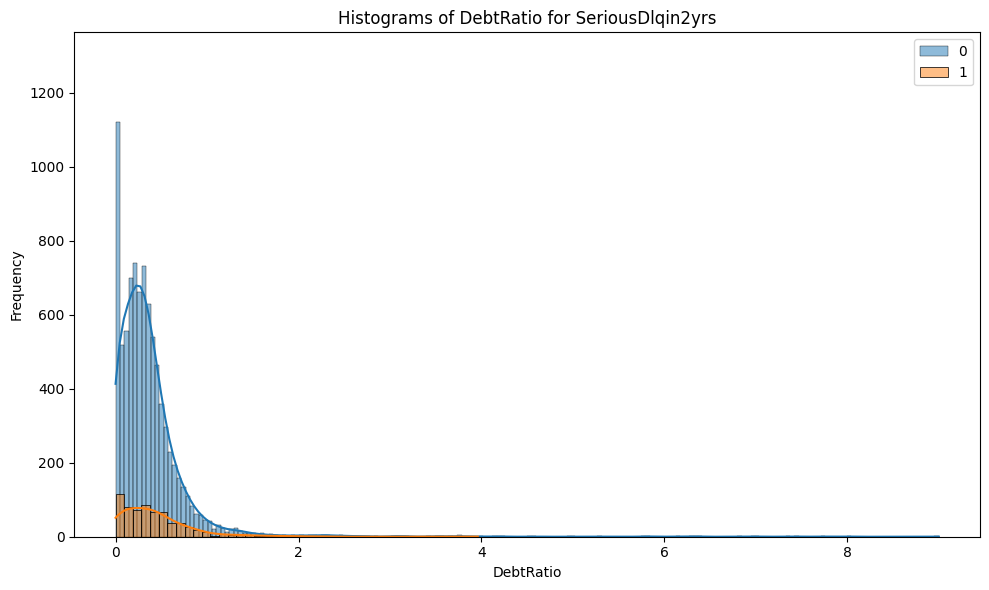

In [48]:
sin_outliers_deuda = train_set["DebtRatio"] < 10
bt.plot_grouped_histograms(train_set[sin_outliers_deuda], cat_col=target, num_col="DebtRatio", group_size=2)


In [49]:
columna_cat = target
columna_num = "DebtRatio"

grupo_a = train_set.loc[train_set[columna_cat] == 0][columna_num]
grupo_b = train_set.loc[train_set[columna_cat] == 1][columna_num]

estadistico_u, p_valor = mannwhitneyu(grupo_a, grupo_b)

print("Estadístico U:", estadistico_u)
print("Valor p:", p_valor)


Estadístico U: 2593400.5
Valor p: 1.735414495731165e-06


In [50]:
p_valor < 0.05


np.True_

In [51]:
features_visual.append("DebtRatio")


In [52]:
features_visual


['N30-59',
 'N60-89',
 'N90',
 'RevolvingUtilizationOfUnsecuredLines',
 'age',
 'MonthlyIncome',
 'DebtRatio']

In [53]:
np.arange(0, 1, 0.1)


array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [54]:
for umbral in np.arange(0, 1, 0.1):
    print(f"Para umbral = {umbral}")
    selector_varianza = VarianceThreshold(umbral)
    selector_varianza.fit(train_set[features_visual])
    print("Lista seleccionada por selector de varianza:", selector_varianza.get_feature_names_out())


Para umbral = 0.0
Lista seleccionada por selector de varianza: ['N30-59' 'N60-89' 'N90' 'RevolvingUtilizationOfUnsecuredLines' 'age'
 'MonthlyIncome' 'DebtRatio']
Para umbral = 0.1
Lista seleccionada por selector de varianza: ['N30-59' 'RevolvingUtilizationOfUnsecuredLines' 'age' 'MonthlyIncome'
 'DebtRatio']
Para umbral = 0.2
Lista seleccionada por selector de varianza: ['N30-59' 'age' 'MonthlyIncome' 'DebtRatio']
Para umbral = 0.30000000000000004
Lista seleccionada por selector de varianza: ['age' 'MonthlyIncome' 'DebtRatio']
Para umbral = 0.4
Lista seleccionada por selector de varianza: ['age' 'MonthlyIncome' 'DebtRatio']
Para umbral = 0.5
Lista seleccionada por selector de varianza: ['age' 'MonthlyIncome' 'DebtRatio']
Para umbral = 0.6000000000000001
Lista seleccionada por selector de varianza: ['age' 'MonthlyIncome' 'DebtRatio']
Para umbral = 0.7000000000000001
Lista seleccionada por selector de varianza: ['age' 'MonthlyIncome' 'DebtRatio']
Para umbral = 0.8
Lista seleccionada por

In [55]:
features_visual


['N30-59',
 'N60-89',
 'N90',
 'RevolvingUtilizationOfUnsecuredLines',
 'age',
 'MonthlyIncome',
 'DebtRatio']

4.4 **Selección por filtrado, Análisis ANOVA y Mutual Information**

In [56]:
features_num


['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents',
 'NumberRealEstateLoansOrLines']

In [57]:
X_train = train_set[features_num]
y_train = train_set[target]


In [58]:
f_classif(X_train, y_train)


(array([7.88269908e+02, 1.05857431e+02, 7.40742353e-05, 6.12426971e+00,
        1.06261534e+01, 2.01252855e+01, 3.14679481e-01]),
 array([1.16190331e-166, 1.06935427e-024, 9.93133162e-001, 1.33512520e-002,
        1.11893938e-003, 7.33882974e-006, 5.74836065e-001]))

In [59]:
X_train = train_set[features_num]
y_train = train_set[target]

selector_num = SelectKBest(f_classif, k=4)
datos_kbest = selector_num.fit_transform(X_train, y_train)

X_train_kbest = pd.DataFrame(datos_kbest, columns=selector_num.get_feature_names_out())
X_train_kbest


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfOpenCreditLinesAndLoans,NumberOfDependents
0,0.039187,61.0,7.0,0.0
1,0.919317,41.0,3.0,0.0
2,0.253718,49.0,19.0,0.0
3,0.249462,26.0,4.0,0.0
4,0.224520,76.0,6.0,0.0
...,...,...,...,...
9447,0.174437,61.0,7.0,0.0
9448,0.039651,64.0,6.0,0.0
9449,1.000000,29.0,0.0,6.0
9450,0.945805,51.0,16.0,0.0


In [60]:
features_filter = list(selector_num.get_feature_names_out())
features_filter


['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents']

In [61]:
features_cat


['N30-59', 'N60-89', 'N90']

In [62]:
X_train = train_set[features_cat]
y_train = train_set[target]

selector_cat = SelectKBest(mutual_info_classif, k=3)
datos_kbest = selector_cat.fit_transform(X_train, y_train)

X_train_kbest = pd.DataFrame(datos_kbest, columns=selector_cat.get_feature_names_out())
X_train_kbest


,N30-59,N60-89,N90
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
...,...,...,...
9447,0,0,0
9448,0,0,0
9449,0,0,0
9450,2,0,0


In [63]:
features_filter += features_cat


In [64]:
mutual_info_classif(X_train, y_train, random_state=42)


array([0.02099067, 0.02201709, 0.03364673])

In [65]:
# Información mutua en bits
mutual_info_classif(X_train, y_train, random_state=42) / np.log(2)


array([0.03028313, 0.03176395, 0.04854197])

In [66]:
features_filter


['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents',
 'N30-59',
 'N60-89',
 'N90']

4.5 **Selección por modelo**

In [67]:
features = features_num + features_cat

rf_para_seleccion = RandomForestClassifier(max_depth=10, random_state=42, class_weight="balanced")

selector_modelo = SelectFromModel(estimator=rf_para_seleccion, threshold="median")  # nos quedamos con la mitad

selector_modelo.fit(train_set[features], train_set[target])

features_modelo = list(selector_modelo.get_feature_names_out())
features_modelo


['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'N30-59', 'N90']

In [68]:
rf_verificacion = RandomForestClassifier(max_depth=10, random_state=42, class_weight="balanced")
rf_verificacion.fit(train_set[features], train_set[target])

df_importancia = pd.DataFrame(rf_verificacion.feature_importances_, columns=["importance"], index=features).sort_values("importance", ascending=False)
df_importancia


,importance
RevolvingUtilizationOfUnsecuredLines,0.329503
N90,0.142324
N30-59,0.114783
age,0.089270
DebtRatio,0.085283
MonthlyIncome,0.069371
N60-89,0.061103
NumberOfOpenCreditLinesAndLoans,0.058234
NumberRealEstateLoansOrLines,0.028565
NumberOfDependents,0.021563


*Cortando por la mediana:*

In [69]:
df_importancia.importance.median()


np.float64(0.07732703494184678)

In [70]:
df_importancia[df_importancia.importance > df_importancia.importance.median()]


,importance
RevolvingUtilizationOfUnsecuredLines,0.329503
N90,0.142324
N30-59,0.114783
age,0.089270
DebtRatio,0.085283


4.6 **RFE**

In [71]:
rf_para_rfe = RandomForestClassifier(max_depth=10, random_state=42, class_weight="balanced")

rfe = RFE(estimator=rf_para_rfe, n_features_to_select=6, step=1)  # itera hasta quedarse con 6
# (n_features - n_features_deseadas) / step

rfe.fit(train_set[features], train_set[target])


,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",RandomForestC...ndom_state=42)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",6
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only available when `estimator` is a classifier.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: ``Estimator`` instanceThe fitted estimator used to select features.,RandomForestClassifier,RandomForestC...ndom_state=42)
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['RevolvingUtilizationOfUnsecuredLines','age','DebtRatio',...,'N30-59', 'N60-89','N90']"
n_features_ n_features_: intThe number of selected features.,int64,np.int64(6)
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,10


In [72]:
features_RFE = list(rfe.get_feature_names_out())
features_RFE


['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'DebtRatio',
 'MonthlyIncome',
 'N30-59',
 'N90']

In [73]:
features_modelo


['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'N30-59', 'N90']

4.7 **Selección Secuencial (SFS)**

In [74]:
train_set[features].columns.tolist()


['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents',
 'NumberRealEstateLoansOrLines',
 'N30-59',
 'N60-89',
 'N90']

In [75]:
40 + 36 + 32 + 28 + 24


160

In [76]:
rf_para_sfs = RandomForestClassifier(max_depth=10, class_weight="balanced", random_state=42)

sfs_forward = SequentialFeatureSelector(
    rf_para_sfs,
    n_features_to_select=5,
    cv=4,
    scoring="balanced_accuracy",  # o, en regresión, p.ej. "neg_root_mean_squared_error"
    n_jobs=1,
)
# cuántos modelos entrena:
# 1ª feature: 10 * 4 = 40
# 2ª feature: 9 * 4 = 36
# 3ª feature: 8 * 4 = 32
# 4ª feature: 7 * 4 = 28
# 5ª feature: 6 * 4 = 24

sfs_forward.fit(train_set[features], train_set[target])


,estimator estimator: estimator instanceAn unfitted estimator.,RandomForestC...ndom_state=42)
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",5
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.",'balanced_accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.",4
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",1
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['RevolvingUtilizationOfUnsecuredLines','age','DebtRatio',...,'N30-59', 'N60-89','N90']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,10
n_features_to_select_ n_features_to_select_: intThe number of features that were selected.,int64,np.int64(5)


In [77]:
features_SFS = list(sfs_forward.get_feature_names_out())
features_SFS


['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfOpenCreditLinesAndLoans',
 'N60-89',
 'N90']

In [78]:
features_RFE


['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'DebtRatio',
 'MonthlyIncome',
 'N30-59',
 'N90']

In [79]:
features_modelo


['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'N30-59', 'N90']

In [80]:
features_filter


['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents',
 'N30-59',
 'N60-89',
 'N90']

In [81]:
features_visual


['N30-59',
 'N60-89',
 'N90',
 'RevolvingUtilizationOfUnsecuredLines',
 'age',
 'MonthlyIncome',
 'DebtRatio']

*Tenemos para todos los gustos.*

4.8 **Hard Voting**

In [82]:
lista_total = features_visual + features_filter + features_modelo + features_RFE + features_SFS
votaciones = Counter(lista_total)
votaciones


Counter({'N90': 5,
         'RevolvingUtilizationOfUnsecuredLines': 5,
         'age': 5,
         'N30-59': 4,
         'N60-89': 3,
         'DebtRatio': 3,
         'MonthlyIncome': 2,
         'NumberOfOpenCreditLinesAndLoans': 2,
         'NumberOfDependents': 1})

In [83]:
escrutinio = pd.DataFrame(votaciones.values(), columns=["Votos"], index=votaciones.keys()).sort_values("Votos", ascending=False)
escrutinio


,Votos
N90,5
age,5
RevolvingUtilizationOfUnsecuredLines,5
N30-59,4
N60-89,3
DebtRatio,3
MonthlyIncome,2
NumberOfOpenCreditLinesAndLoans,2
NumberOfDependents,1


In [84]:
features_hard_voting = escrutinio["Votos"].nlargest(6).index.to_list()
features_hard_voting


['N90',
 'age',
 'RevolvingUtilizationOfUnsecuredLines',
 'N30-59',
 'N60-89',
 'DebtRatio']

5. **Modelado**

In [85]:
nombres_listas = [f"Seleccion {n}" for n in ["visual", "filter", "modelo", "rfe", "sfs", "voting"]]
nombres_modelos = ["Random Forest", "HistGradientBoosting", "AdaBoost"]

peso_positivo = len(train_set[train_set[target] == 0]) / len(train_set[train_set[target] == 1])

rf_clf = RandomForestClassifier(max_depth=10, class_weight="balanced", random_state=42)
hgb_clf = HistGradientBoostingClassifier(max_depth=4, random_state=42, class_weight="balanced")
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42),
    random_state=42,
)

modelos = [rf_clf, hgb_clf, ada_clf]
resultados = []

for indice, lista_features in enumerate([features_visual, features_filter, features_modelo, features_RFE, features_SFS, features_hard_voting]):
    X_train = train_set[lista_features]
    y_train = train_set[target]

    for nombre_modelo, modelo in zip(nombres_modelos, modelos):
        metrica = np.mean(cross_val_score(modelo, X_train, y_train, cv=5, scoring="balanced_accuracy"))
        fila = {
            "features_list": nombres_listas[indice],
            "model": nombre_modelo,
            "avg. recall": metrica,
        }
        print(fila)
        resultados.append(fila.copy())

df_resultados = pd.DataFrame(resultados)
df_resultados.sort_values("avg. recall", ascending=False)


{'features_list': 'Seleccion visual', 'model': 'Random Forest', 'avg. recall': np.float64(0.7206555061843982)}
{'features_list': 'Seleccion visual', 'model': 'HistGradientBoosting', 'avg. recall': np.float64(0.7549785139874754)}
{'features_list': 'Seleccion visual', 'model': 'AdaBoost', 'avg. recall': np.float64(0.7072427728821197)}
{'features_list': 'Seleccion filter', 'model': 'Random Forest', 'avg. recall': np.float64(0.7334352450127002)}
{'features_list': 'Seleccion filter', 'model': 'HistGradientBoosting', 'avg. recall': np.float64(0.7568250729621055)}
{'features_list': 'Seleccion filter', 'model': 'AdaBoost', 'avg. recall': np.float64(0.7131913619355624)}
{'features_list': 'Seleccion modelo', 'model': 'Random Forest', 'avg. recall': np.float64(0.71916206440985)}
{'features_list': 'Seleccion modelo', 'model': 'HistGradientBoosting', 'avg. recall': np.float64(0.7448963623320086)}
{'features_list': 'Seleccion modelo', 'model': 'AdaBoost', 'avg. recall': np.float64(0.7042783404449369

,features_list,model,avg. recall
4,Seleccion filter,HistGradientBoosting,0.756825
16,Seleccion voting,HistGradientBoosting,0.755728
1,Seleccion visual,HistGradientBoosting,0.754979
13,Seleccion sfs,HistGradientBoosting,0.751010
7,Seleccion modelo,HistGradientBoosting,0.744896
10,Seleccion rfe,HistGradientBoosting,0.744316
12,Seleccion sfs,Random Forest,0.738889
3,Seleccion filter,Random Forest,0.733435
0,Seleccion visual,Random Forest,0.720656
6,Seleccion modelo,Random Forest,0.719162


In [86]:
features_SFS


['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfOpenCreditLinesAndLoans',
 'N60-89',
 'N90']

6. **Ajuste fino y evaluación**

In [87]:
distribucion_hiperparametros = {
    "max_iter": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 8, None],
    "min_samples_leaf": [5, 10, 20, 50],
    "l2_regularization": [0.0, 0.1, 1.0],
    "class_weight": ["balanced", None],
}

hgb_grid = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_distributions=distribucion_hiperparametros,
    n_iter=15,
    cv=5,
    scoring="balanced_accuracy",
    random_state=42,
    n_jobs=1,
)
hgb_grid.fit(train_set[features_SFS], y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",HistGradientB...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': ['balanced', None], 'l2_regularization': [0.0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV

In [88]:
hgb_grid.best_params_


{'min_samples_leaf': 5,
 'max_iter': 100,
 'max_depth': 3,
 'learning_rate': 0.05,
 'l2_regularization': 0.1,
 'class_weight': 'balanced'}

In [89]:
hgb_grid.best_score_


np.float64(0.7592137474703493)

In [90]:
X_test = test_set[features_SFS]
y_test = test_set[target]


In [91]:
y_pred = hgb_grid.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.77      0.86      2198
           1       0.20      0.75      0.31       166

    accuracy                           0.77      2364
   macro avg       0.59      0.76      0.59      2364
weighted avg       0.92      0.77      0.82      2364



In [92]:
features_SFS


['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfOpenCreditLinesAndLoans',
 'N60-89',
 'N90']

In [93]:
hgb_grid_2 = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_distributions=distribucion_hiperparametros,
    n_iter=15,
    cv=5,
    scoring="balanced_accuracy",
    random_state=42,
    n_jobs=1,
)
hgb_grid_2.fit(train_set[features_filter], y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",HistGradientB...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': ['balanced', None], 'l2_regularization': [0.0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV

In [94]:
hgb_grid_2.best_params_


{'min_samples_leaf': 5,
 'max_iter': 100,
 'max_depth': 3,
 'learning_rate': 0.05,
 'l2_regularization': 0.1,
 'class_weight': 'balanced'}

In [95]:
hgb_grid_2.best_score_


np.float64(0.7699545873204928)

In [96]:
X_test = test_set[features_filter]
y_test = test_set[target]


In [97]:
y_pred = hgb_grid_2.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.78      0.87      2198
           1       0.21      0.77      0.33       166

    accuracy                           0.78      2364
   macro avg       0.59      0.77      0.60      2364
weighted avg       0.92      0.78      0.83      2364



In [98]:
features_filter


['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents',
 'N30-59',
 'N60-89',
 'N90']

In [99]:
hgb_grid_3 = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_distributions=distribucion_hiperparametros,
    n_iter=15,
    cv=5,
    scoring="balanced_accuracy",
    random_state=42,
    n_jobs=1,
)
hgb_grid_3.fit(train_set[features], y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",HistGradientB...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': ['balanced', None], 'l2_regularization': [0.0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV

In [100]:
hgb_grid_3.best_params_


{'min_samples_leaf': 5,
 'max_iter': 100,
 'max_depth': 3,
 'learning_rate': 0.05,
 'l2_regularization': 0.1,
 'class_weight': 'balanced'}

In [101]:
hgb_grid_3.best_score_


np.float64(0.7635054631924527)

In [102]:
X_test = test_set[features]
y_test = test_set[target]


In [103]:
y_pred = hgb_grid_3.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.78      0.87      2198
           1       0.21      0.75      0.33       166

    accuracy                           0.78      2364
   macro avg       0.59      0.77      0.60      2364
weighted avg       0.92      0.78      0.83      2364



In [104]:
features


['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents',
 'NumberRealEstateLoansOrLines',
 'N30-59',
 'N60-89',
 'N90']

### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de
la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador
de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.

In [105]:
X_train = train_set[features]
X_test = test_set[features]
y_train = train_set[target]
y_test = test_set[target]

# Escalamos antes de PCA: sin esto, MonthlyIncome (varianza ~1.6e8 en bruto) domina la
# varianza total y la primera componente principal termina siendo casi un alias de esa
# única variable.
escalador = StandardScaler()
X_train_escalado = escalador.fit_transform(X_train)
X_test_escalado = escalador.transform(X_test)

pca = PCA()
pca.fit(X_train_escalado)


,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [106]:
pca.explained_variance_ratio_


array([0.19996622, 0.14943298, 0.11955877, 0.10242465, 0.0915658 ,
       0.07949892, 0.07115988, 0.0697001 , 0.06242945, 0.05426323])

------------------------------------------
Porcentaje de varianza explicada acumulada
------------------------------------------
[0.19996622 0.3493992  0.46895797 0.57138262 0.66294842 0.74244734
 0.81360722 0.88330732 0.94573677 1.        ]


Text(0, 0.5, 'Por. varianza acumulada')

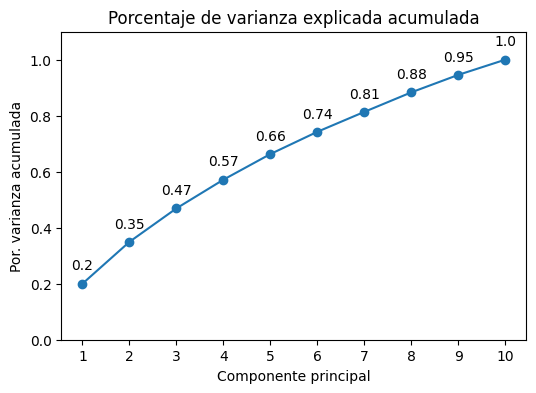

In [107]:
varianza_acumulada = pca.explained_variance_ratio_.cumsum()
print("------------------------------------------")
print("Porcentaje de varianza explicada acumulada")
print("------------------------------------------")
print(varianza_acumulada)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
ax.plot(np.arange(len(X_train.columns)) + 1, varianza_acumulada, marker="o")

for x, y in zip(np.arange(len(X_train.columns)) + 1, varianza_acumulada):
    etiqueta = round(y, 2)
    ax.annotate(etiqueta, (x, y), textcoords="offset points", xytext=(0, 10), ha="center")

ax.set_ylim(0, 1.1)
ax.set_xticks(np.arange(pca.n_components_) + 1)
ax.set_title("Porcentaje de varianza explicada acumulada")
ax.set_xlabel("Componente principal")
ax.set_ylabel("Por. varianza acumulada")


In [108]:
X_train_pca = pca.transform(X_train_escalado)
X_test_pca = pca.transform(X_test_escalado)
hgb_pca = HistGradientBoostingClassifier(**hgb_grid_2.best_params_)


In [109]:
hgb_pca.fit(X_train_pca[:, :1], y_train)
y_pred = hgb_pca.predict(X_test_pca[:, :1])
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.97      0.85      0.90      2198
           1       0.23      0.63      0.34       166

    accuracy                           0.83      2364
   macro avg       0.60      0.74      0.62      2364
weighted avg       0.92      0.83      0.86      2364



In [110]:
hgb_pca = HistGradientBoostingClassifier(**hgb_grid_2.best_params_)


In [111]:
hgb_pca.fit(X_train_pca[:, :1], y_train)
y_pred = hgb_pca.predict(X_test_pca[:, :1])
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.97      0.85      0.90      2198
           1       0.23      0.63      0.34       166

    accuracy                           0.83      2364
   macro avg       0.60      0.74      0.62      2364
weighted avg       0.92      0.83      0.86      2364



In [112]:
hgb_pca.fit(X_train_pca[:, :7], y_train)
y_pred = hgb_pca.predict(X_test_pca[:, :7])
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.81      0.89      2198
           1       0.22      0.73      0.34       166

    accuracy                           0.80      2364
   macro avg       0.60      0.77      0.61      2364
weighted avg       0.92      0.80      0.85      2364

